<a href="https://colab.research.google.com/github/mohammadreza-mohammadi94/Alzheimer-Risk-Assessment-WebApp/blob/master/PyTorch_Faradars/22_DCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Generative Adversarial Networks**
* [Generative Adversarial Networks](https://proceedings.neurips.cc/paper/2014/file/5ca3e9b122f61f8f06494c97b1afccf3-Paper.pdf)


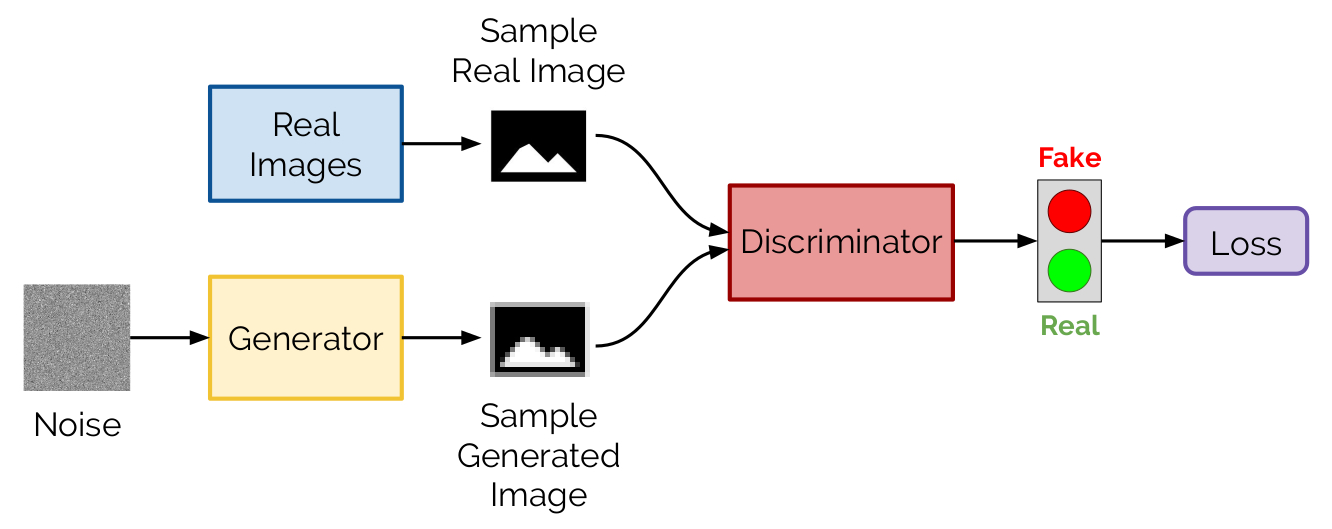

## **Deep Convolutional Generative Adversarial Network**

* [Unsupervised Representation Learning with Deep Convolutional Adversarial Networks](https://arxiv.org/pdf/1511.06434v1.pdf)


**Generator Architecture**

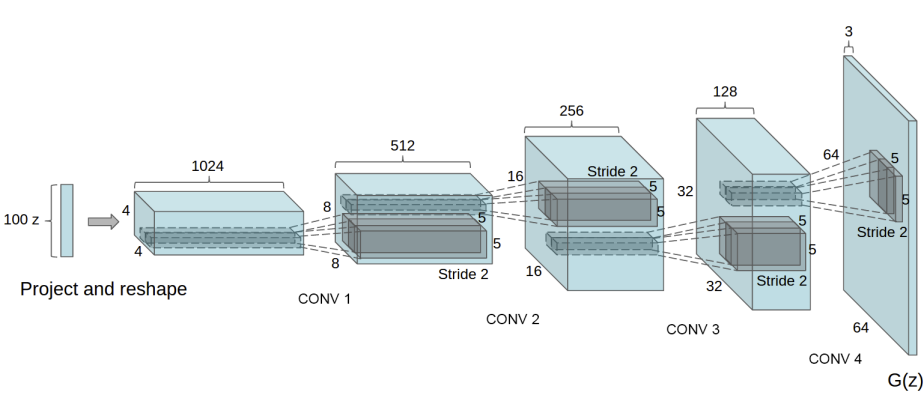

___________________________

**Guidelines for stable Deep Convolutional GANs:**

*   Replace any pooling layers with strided convolutions    (discriminator) and fractional-strided
convolutions (generator).
*   Use batchnorm in both the generator and the discriminator.
*   Remove fully connected hidden layers for deeper architectures.
*   Use ReLU activation in generator for all layers except for the output, which uses Tanh.
*   Use LeakyReLU activation in the discriminator for all layers


___________________________

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [53]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 128
z_dim = 100 # 100-dimensional noise vector as the input to Generator
num_epochs = 4
learning_rate = 0.0002 # Optimizer learning rate
beta1 = 0.5 # Momentum value for Adam optimizer

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_PASS"] = userdata.get('KAGGLE_PASS')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
 99% 1.31G/1.33G [00:05<00:00, 228MB/s]
100% 1.33G/1.33G [00:06<00:00, 238MB/s]


In [ ]:
!unzip "/content/celeba-dataset.zip"

In [ ]:
root = "/content/img_align_celeba"
dataset = datasets.ImageFolder(root = root,
                               transform = transforms.Compose([
                                   transforms.Resize(64),
                                   transforms.CenterCrop(64),
                                   transforms.ToTensor(),
                                   transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                               ]))

In [ ]:
dataloader = DataLoader(dataset,
                        batch_size=batch_size,
                        shuffle=True,
                        num_workers=8)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


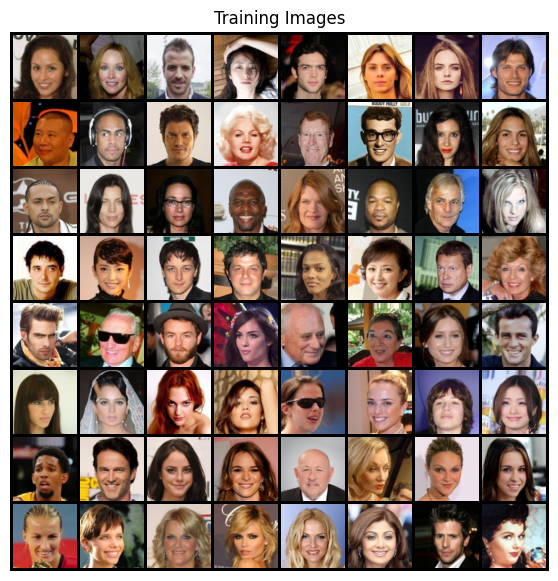

In [ ]:
# Check few pictures
real_batch = next(iter(dataloader))
plt.figure(figsize=(7, 7))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=3, normalize=True).cpu(),(1, 2, 0)));

# Model Implementation
Weight Initialization

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight.data, mean=0.0, std=0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight.data, mean=1.0, std=0.02)
        torch.nn.init.constant_(m.bias, val=0)

The `init_weights` method initializes the weights of layers in a DCGAN, ensuring stable training. It sets the weights of convolutional and transposed convolutional layers using a normal distribution (mean `0.0`, std `0.02`). For batch normalization layers, it initializes the weights with a mean of `1.0` and std of `0.02`, while setting the bias to `0`. This careful initialization helps prevent issues like vanishing or exploding gradients, promoting smooth training.

# Discriminator Model

In [ ]:
discriminator = nn.Sequential(
    nn.Conv2d(in_channels=3,
              out_channels=64,
              kernel_size=4,
              stride=2,
              padding=1,
              bias=False),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(in_channels=64,
              out_channels=128,
              kernel_size=4,
              stride=2,
              padding=1,
              bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(in_channels=128,
              out_channels=256,
              kernel_size=4,
              stride=2,
              padding=1,
              bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(in_channels=256,
              out_channels=512,
              kernel_size=4,
              stride=2,
              padding=1,
              bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),

    nn.Conv2d(512,
              1,
              kernel_size=4,
              stride=1,
              padding=0,
              bias=False),
    nn.Sigmoid()
)

disc = discriminator.to(device)
disc.apply(init_weights)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (1): LeakyReLU(negative_slope=0.2, inplace=True)
  (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.2, inplace=True)
  (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.2, inplace=True)
  (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): LeakyReLU(negative_slope=0.2, inplace=True)
  (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (12): Sigmoid()
)

# Generator Model

In [ ]:
generator = nn.Sequential(

    nn.ConvTranspose2d(z_dim,
                       512,
                       kernel_size=4,
                       stride=1,
                       padding=0,
                       bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),

    nn.ConvTranspose2d(512,
                       256,
                       kernel_size=4,
                       stride=2,
                       padding=1,
                       bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),

    nn.ConvTranspose2d(256,
                       128,
                       kernel_size=4,
                       stride=2,
                       padding=1,
                       bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.ConvTranspose2d(128,
                       64,
                       kernel_size=4,
                       stride=2,
                       padding=1,
                       bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    nn.ConvTranspose2d(64,
                       3,
                       kernel_size=4,
                       stride=2,
                       padding=1,
                       bias=False), # Output Layer
    nn.Tanh()
)

gen = generator.to(device)
gen.apply(init_weights)

Sequential(
  (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  (13): Tanh()
)

### Definning Criterion & Optimizers

In [ ]:
criterion = nn.BCELoss()
disc_optim = optim.Adam(disc.parameters(),
                        lr=learning_rate,
                        betas=(beta1, 0.999))
gen_optim = optim.Adam(gen.parameters(),
                       lr=learning_rate,
                       betas=(beta1, 0.999))

fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)
real_label=1.
fake_label=0.

# Training Loop

In [54]:
D_losses = []
G_losses = []
img_list = []
iters = 0


for epoch in range(num_epochs):
    for i, batch in enumerate(dataloader):

        disc.zero_grad()
        real_images = batch[0].to(device)
        batch_size = real_images.size(0)
        label = torch.full((batch_size,), real_label, dtype=torch.float, device=device)
        output = disc(real_images).view(-1) # Pass train images (real) to the disc.
        disc_error_real = criterion(output, label)
        disc_error_real.backward()

        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake = gen(noise)
        label.fill_(fake_label)
        output = disc(fake.detach()).view(-1) # Pass fake images to the disc.
        disc_error_fake = criterion(output, label)
        disc_error_fake.backward() # Backprop
        disc_error = disc_error_real + disc_error_fake
        disc_optim.step() # Update disc

        gen.zero_grad()
        label.fill_(real_label)
        output = disc(fake).view(-1) # Pass fake images to the update disc.
        gen_error = criterion(output, label) # Gen loss based on the cases in which disc is wrong.
        gen_error.backward() # Backpropagation
        gen_optim.step() # Update gen

        if i % 200 == 0:
            print(f'Epoch{[epoch+1]} | Batch[{i}/{len(dataloader)}] | Disc-Loss: {disc_error.item():.4f} | Gen-Loss: {gen_error.item():.4f}')


        G_losses.append(gen_error.item())
        D_losses.append(disc_error.item())


        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = gen(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch[1] | Batch[0/1583] | Disc-Loss: 0.1214 | Gen-Loss: 4.3854
Epoch[1] | Batch[200/1583] | Disc-Loss: 0.0721 | Gen-Loss: 5.0831
Epoch[1] | Batch[400/1583] | Disc-Loss: 0.2041 | Gen-Loss: 3.9133
Epoch[1] | Batch[600/1583] | Disc-Loss: 0.2012 | Gen-Loss: 3.4317
Epoch[1] | Batch[800/1583] | Disc-Loss: 0.1455 | Gen-Loss: 4.2512
Epoch[1] | Batch[1000/1583] | Disc-Loss: 0.0674 | Gen-Loss: 4.9650
Epoch[1] | Batch[1200/1583] | Disc-Loss: 0.3860 | Gen-Loss: 2.9423
Epoch[1] | Batch[1400/1583] | Disc-Loss: 0.5889 | Gen-Loss: 1.6892
Epoch[2] | Batch[0/1583] | Disc-Loss: 0.3059 | Gen-Loss: 5.8602
Epoch[2] | Batch[200/1583] | Disc-Loss: 0.0932 | Gen-Loss: 4.4886
Epoch[2] | Batch[400/1583] | Disc-Loss: 0.3845 | Gen-Loss: 3.9673
Epoch[2] | Batch[600/1583] | Disc-Loss: 0.1544 | Gen-Loss: 5.2858
Epoch[2] | Batch[800/1583] | Disc-Loss: 0.0895 | Gen-Loss: 5.0467
Epoch[2] | Batch[1000/1583] | Disc-Loss: 0.1120 | Gen-Loss: 4.6615
Epoch[2] | Batch[1200/1583] | Disc-Loss: 0.5044 | Gen-Loss: 3.4721
Epoch[2] 

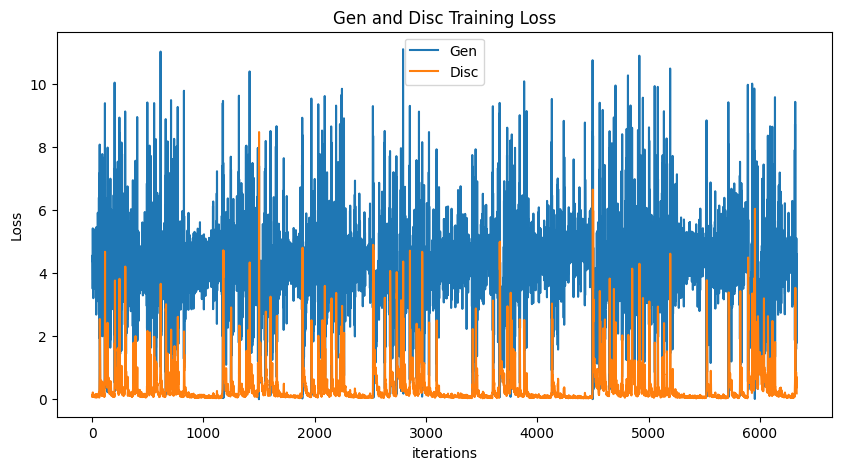

In [55]:
plt.figure(figsize=(10,5))
plt.title("Gen and Disc Training Loss")
plt.plot(G_losses,label="Gen")
plt.plot(D_losses,label="Disc")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [56]:
fig = plt.figure(figsize=(8, 8))
plt.axis("off")
imgs = [[plt.imshow(np.transpose(i,(1, 2, 0)), animated=True)] for i in img_list]
ani = animation.ArtistAnimation(fig, imgs, interval=1000, repeat_delay=1000, blit=True)

HTML(ani.to_jshtml())